In [66]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [67]:
# ============================================================
# STEP 1: SELECT ONLY NUMERIC COLUMNS (no categorical yet)
# ============================================================

df= pd.read_csv("AmesHousing.csv")
df.describe()  
num_col = df.select_dtypes(include=[np.number])
droped_col = ["Order", "PID", "MS SubClass", "SalePrice"]
X = num_col.drop(columns=droped_col)
y = num_col["SalePrice"]

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]}")

Features: 35
Samples:  2930


In [68]:

# ============================================================
# STEP 2: HANDLE MISSING VALUES
# ============================================================
print(f"\nMissing values per column:")

missing = X.isnull().sum()
print(missing[X.isnull().sum()>0])
X= X.fillna(X.median())

print(f"\nAfter filling: {X.isnull().sum().sum()} missing values")




Missing values per column:
Lot Frontage      490
Mas Vnr Area       23
BsmtFin SF 1        1
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Bsmt Full Bath      2
Bsmt Half Bath      2
Garage Yr Blt     159
Garage Cars         1
Garage Area         1
dtype: int64

After filling: 0 missing values


In [69]:

# ============================================================
# STEP 3: TRAIN/TEST SPLIT
# ============================================================


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")


Train: 2344, Test: 586


In [70]:

# ============================================================
# STEP 4: BASELINE MODEL
# ============================================================

def show_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {label} ---")
    print(f"MAE:  ${mae:,.0f}")
    print(f"RMSE: ${rmse:,.0f}")
    print(f"R2:   {r2:.4f}")
    return r2

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = show_metrics(y_train, train_pred, "TRAIN")
test_r2 = show_metrics(y_test, test_pred, "TEST")

print(f"\nTrain R2 - Test R2 = {train_r2 - test_r2:.4f}")



--- TRAIN ---
MAE:  $20,253
RMSE: $31,917
R2:   0.8287

--- TEST ---
MAE:  $21,860
RMSE: $36,307
R2:   0.8356

Train R2 - Test R2 = -0.0069



--------------- Feature Importance ------------------
All features ranked by |correlation with target|:
Overall Qual       0.795298
Gr Liv Area        0.698315
Garage Cars        0.644218
Garage Area        0.633081
Total Bsmt SF      0.612108
1st Flr SF         0.607433
Year Built         0.545409
Full Bath          0.542053
Year Remod/Add     0.517653
Garage Yr Blt      0.497365
Mas Vnr Area       0.484157
TotRms AbvGrd      0.475455
Fireplaces         0.467501
BsmtFin SF 1       0.423841
Wood Deck SF       0.333045
Lot Frontage       0.310803
Open Porch SF      0.297722
Bsmt Full Bath     0.286825
Half Bath          0.285369
2nd Flr SF         0.278977
Lot Area           0.261336
Bsmt Unf SF        0.163624
Bedroom AbvGr      0.149269
Screen Porch       0.136936
Enclosed Porch     0.130722
Kitchen AbvGr      0.115860
Overall Cond       0.104085
Pool Area          0.079020
Yr Sold            0.037686
3Ssn Porch         0.034845
Mo Sold            0.030714
BsmtFin SF 2       0.027357

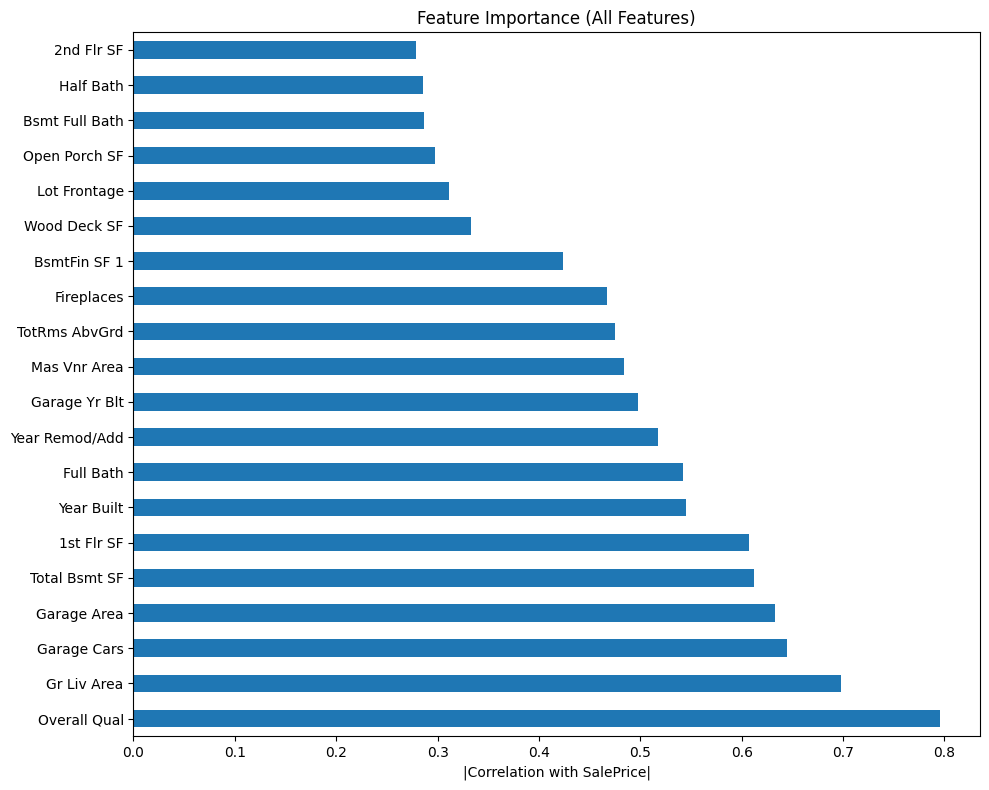

In [71]:
#============================================================
# STEP 5: Correlation Check ( with target and with each other)
# ============================================================

print(f"\n--------------- Feature Importance ------------------")
importance = X_train.corrwith(y_train).abs().sort_values(ascending= False)

print("All features ranked by |correlation with target|:")

print(importance)


# Plot top 20 for readability
plt.figure(figsize=(10, 8))
importance.head(20).plot(kind='barh')
plt.xlabel('|Correlation with SalePrice|')
plt.title('Feature Importance (All Features)')
plt.tight_layout()
plt.savefig('ames_feature_importance.png')
plt.show()




--- Multicollinearity Check ---


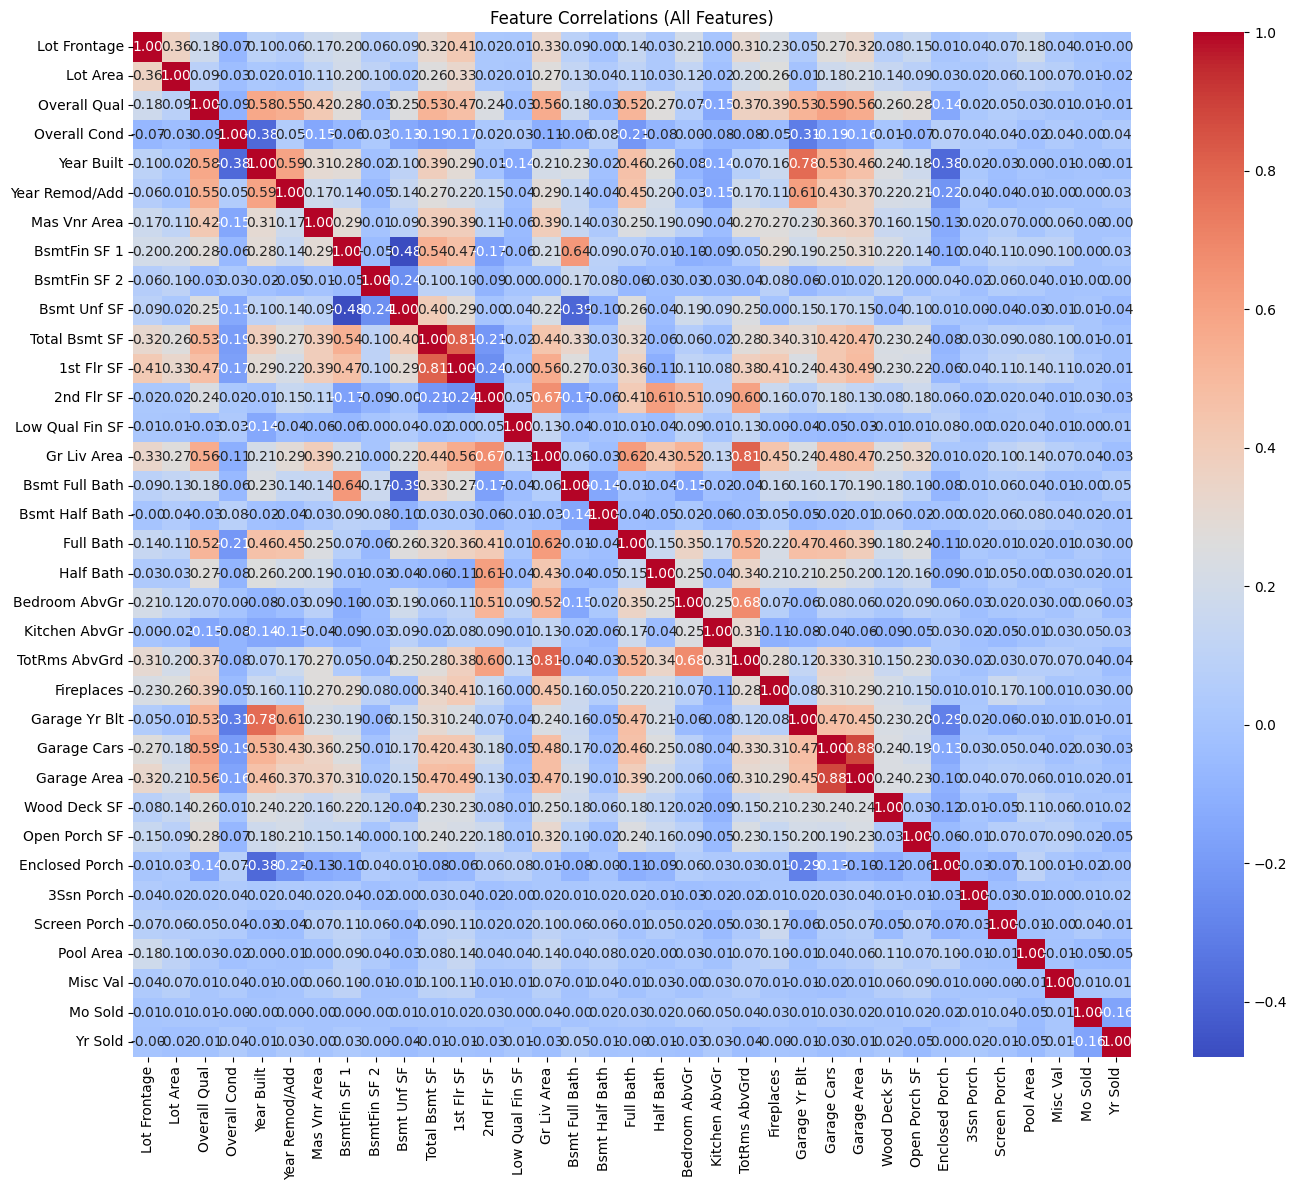


High correlations (|r| > 0.7):
  Year Built - Garage Yr Blt: 0.781
  Total Bsmt SF - 1st Flr SF: 0.814
  Gr Liv Area - TotRms AbvGrd: 0.806
  Garage Cars - Garage Area: 0.884


In [72]:

# ============================================================
# STEP 5: MULTICOLLINEARITY CHECK (on ALL features)
# ============================================================


print("\n--- Multicollinearity Check ---")
corr = X_train.corr()

plt.figure(figsize=(14, 12))
import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations (All Features)')
plt.tight_layout()
plt.show()

# Find high correlation pairs
print("\nHigh correlations (|r| > 0.7):")
high_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            high_pairs.append((corr.columns[i], corr.columns[j], r))
            print(f"  {corr.columns[i]} - {corr.columns[j]}: {r:.3f}")

In [73]:

# ============================================================
# STEP 6: DROP FROM CORRELATED PAIRS (keep higher target correlation)
# ============================================================

features_to_drop = []

for feat1, feat2, r in high_pairs:
    corr1 = importance.get(feat1, 0)
    corr2 = importance.get(feat2, 0)
    
    if corr1 > corr2:
        drop = feat2
        keep = feat1
    else:
        drop = feat1
        keep = feat2
    
    if drop not in features_to_drop:
        features_to_drop.append(drop)
        print(f"\nPair: {feat1} (r_target={corr1:.3f}) vs {feat2} (r_target={corr2:.3f})")
        print(f"  Correlation: {r:.3f}")
        print(f"  → Keep {keep}, Drop {drop}")

# Also drop features with |correlation| < 0.05 (truly weak)
weak = importance[importance < 0.05].index.tolist()
for feat in weak:
    if feat not in features_to_drop:
        features_to_drop.append(feat)
        print(f"\nWeak feature dropped: {feat} (|r|={importance[feat]:.3f})")

print(f"\nFinal drop list: {features_to_drop}")
print(f"Keeping: {[c for c in X_train.columns if c not in features_to_drop]}")

X_train_clean = X_train.drop(columns=features_to_drop)
X_test_clean = X_test.drop(columns=features_to_drop)

print(f"\nFeatures before: {X_train.shape[1]}")
print(f"Features after:  {X_train_clean.shape[1]}")


Pair: Year Built (r_target=0.545) vs Garage Yr Blt (r_target=0.497)
  Correlation: 0.781
  → Keep Year Built, Drop Garage Yr Blt

Pair: Total Bsmt SF (r_target=0.612) vs 1st Flr SF (r_target=0.607)
  Correlation: 0.814
  → Keep Total Bsmt SF, Drop 1st Flr SF

Pair: Gr Liv Area (r_target=0.698) vs TotRms AbvGrd (r_target=0.475)
  Correlation: 0.806
  → Keep Gr Liv Area, Drop TotRms AbvGrd

Pair: Garage Cars (r_target=0.644) vs Garage Area (r_target=0.633)
  Correlation: 0.884
  → Keep Garage Cars, Drop Garage Area

Weak feature dropped: Yr Sold (|r|=0.038)

Weak feature dropped: 3Ssn Porch (|r|=0.035)

Weak feature dropped: Mo Sold (|r|=0.031)

Weak feature dropped: BsmtFin SF 2 (|r|=0.027)

Weak feature dropped: Bsmt Half Bath (|r|=0.024)

Weak feature dropped: Misc Val (|r|=0.018)

Weak feature dropped: Low Qual Fin SF (|r|=0.016)

Final drop list: ['Garage Yr Blt', '1st Flr SF', 'TotRms AbvGrd', 'Garage Area', 'Yr Sold', '3Ssn Porch', 'Mo Sold', 'BsmtFin SF 2', 'Bsmt Half Bath', 'Mi

In [ ]:
# ============================================================
# STEP 7: BASELINE MODEL (Clean Features)
# ============================================================

print("\n--------------- Baseline (Clean) ------------------")

model_clean = LinearRegression()
model_clean.fit(X_train_clean, y_train)

clean_pred = model_clean.predict(X_test_clean)
clean_r2 = r2_score(y_test, clean_pred)

print(f"Clean model R²: {clean_r2:.4f}")
print(f"Features used: {X_train_clean.shape[1]}")



--------------- Baseline (Clean) ------------------
Clean model R²: 0.8309
Features used: 24



--------------- Assumption Checks ------------------


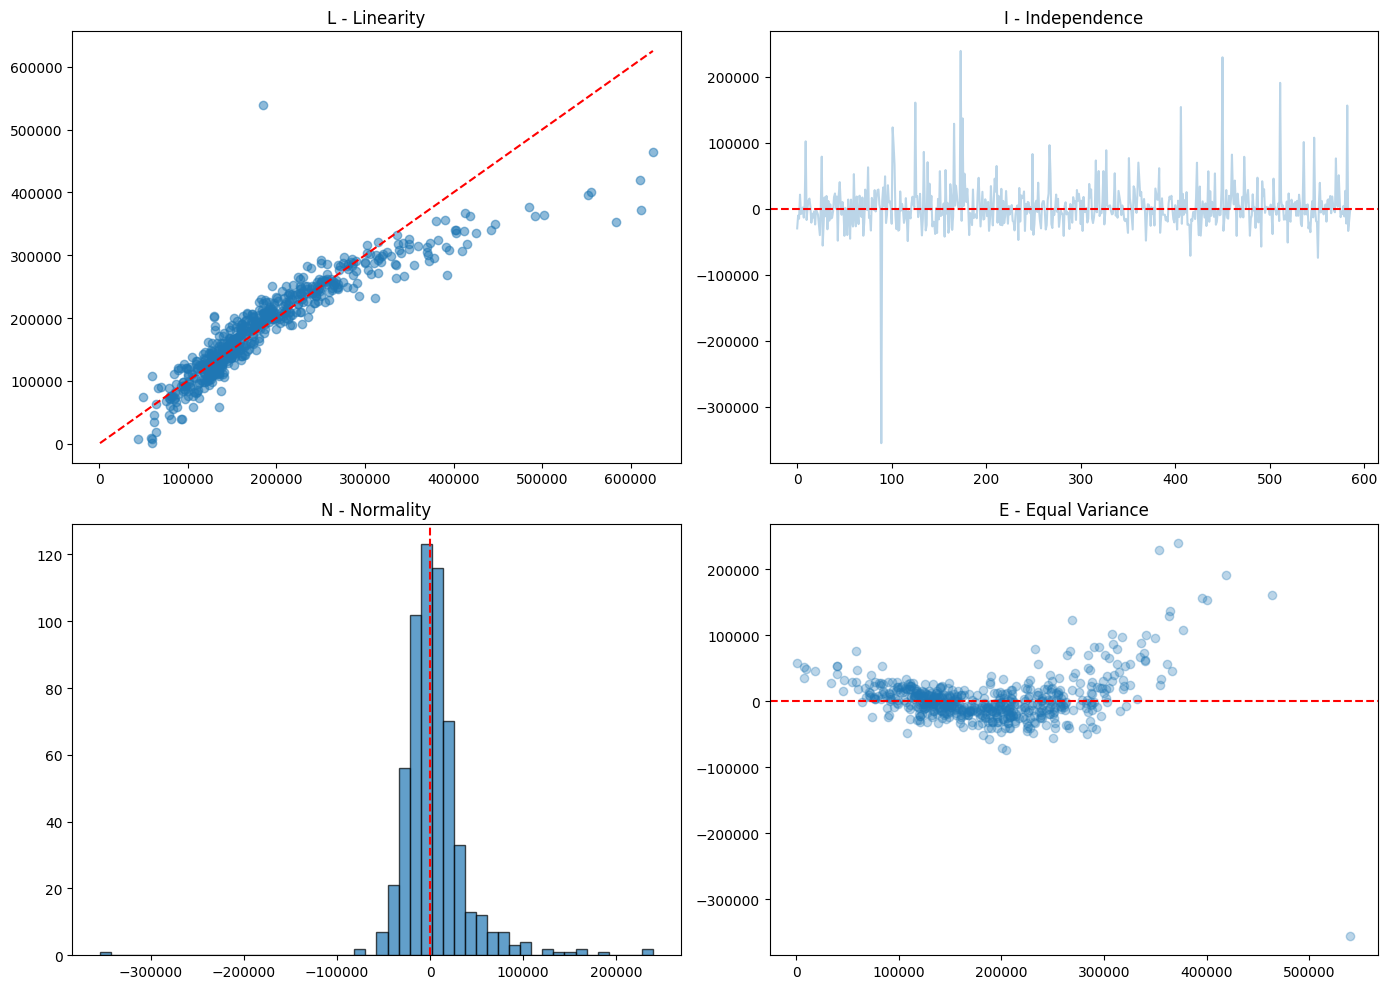


Breusch-Pagan p: 0.0000
D'Agostino p:    0.0000


In [75]:

# ============================================================
# STEP 8: ASSUMPTION CHECKS (Clean Model)
# ============================================================

print("\n--------------- Assumption Checks ------------------")

residuals = y_test - clean_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# L - Linearity
axes[0, 0].scatter(y_test, clean_pred, alpha=0.5)
min_val = min(y_test.min(), clean_pred.min())
max_val = max(y_test.max(), clean_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0, 0].set_title('L - Linearity')

# I - Independence
axes[0, 1].plot(range(len(residuals)), residuals.values, alpha=0.3)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_title('I - Independence')

# N - Normality
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title('N - Normality')

# E - Equal Variance
axes[1, 1].scatter(clean_pred, residuals, alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('E - Equal Variance')

plt.tight_layout()
plt.savefig('ames_assumptions_clean.png', dpi=150)
plt.show()

# Formal tests
bp_clean = het_breuschpagan(residuals, sm.add_constant(X_test_clean))
dagostino_clean = stats.normaltest(residuals)

print(f"\nBreusch-Pagan p: {bp_clean[1]:.4f}")
print(f"D'Agostino p:    {dagostino_clean[1]:.4f}")


In [95]:
# ============================================================
# STEP 8: FEATURE ENGINEERING (Fix What Broke in Step 7)
# ============================================================


print("\n" + "="*60)
print("STEP 8: FEATURE ENGINEERING")
print("="*60)

#  log transformation (fix linearity - equal variance)

print(f"\n--- 8a: Log Transform Target ---")
print(f"Target skew before: {y_train.skew():.2f}")

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"\n target skew after: {y_train_log.skew():.2f}")
print("Goal: closer to 0 = more normal")

#  Polynomial for top feature (fixes non-linearity)


print(f"\n---  Polynomial for: OverallQual_sq, GrLivArea_sq ---")

X_train_eng = X_train_clean.copy()
X_test_eng = X_test_clean.copy()


# Add squared term for top 1–2 features only
X_train_eng['OverallQual_sq'] = X_train_clean['Overall Qual'] ** 2
X_test_eng['OverallQual_sq'] = X_test_clean['Overall Qual'] ** 2

X_train_eng['GrLivArea_sq'] = X_train_clean['Gr Liv Area'] ** 2
X_test_eng[f'GrLivArea_sq'] = X_test_clean["Gr Liv Area"] ** 2


# 8c: Interaction — quality × size (rich areas with big houses = premium)
if 'Overall Qual' in X_train_clean.columns and 'Gr Liv Area' in X_train_clean.columns:
    X_train_eng['Qual_x_Area'] = X_train_clean['Overall Qual'] * X_train_clean['Gr Liv Area']
    X_test_eng['Qual_x_Area'] = X_test_clean['Overall Qual'] * X_test_clean['Gr Liv Area']
    print("Added: Qual_x_Area")

# House age (newer = more expensive, but very old = vintage premium?)
if 'Year Built' in X_train_clean.columns:
    X_train_eng['HouseAge'] = 2026 - X_train_clean['Year Built']
    X_test_eng['HouseAge'] = 2026 - X_test_clean['Year Built']
    print("Added: HouseAge")



print(f"\nFeatures before: {X_train_clean.shape[1]}")
print(f"Features after:  {X_train_eng.shape[1]}")




STEP 8: FEATURE ENGINEERING

--- 8a: Log Transform Target ---
Target skew before: 1.75

 target skew after: -0.09
Goal: closer to 0 = more normal

---  Polynomial for: OverallQual_sq, GrLivArea_sq ---
Added: Qual_x_Area
Added: HouseAge

Features before: 24
Features after:  28



--------------- MODEL after feature eng ------------------

--- Test ---
MAE:  $17,138
RMSE: $28,331
R2:   0.8999

--------------- Assumption Checks ------------------


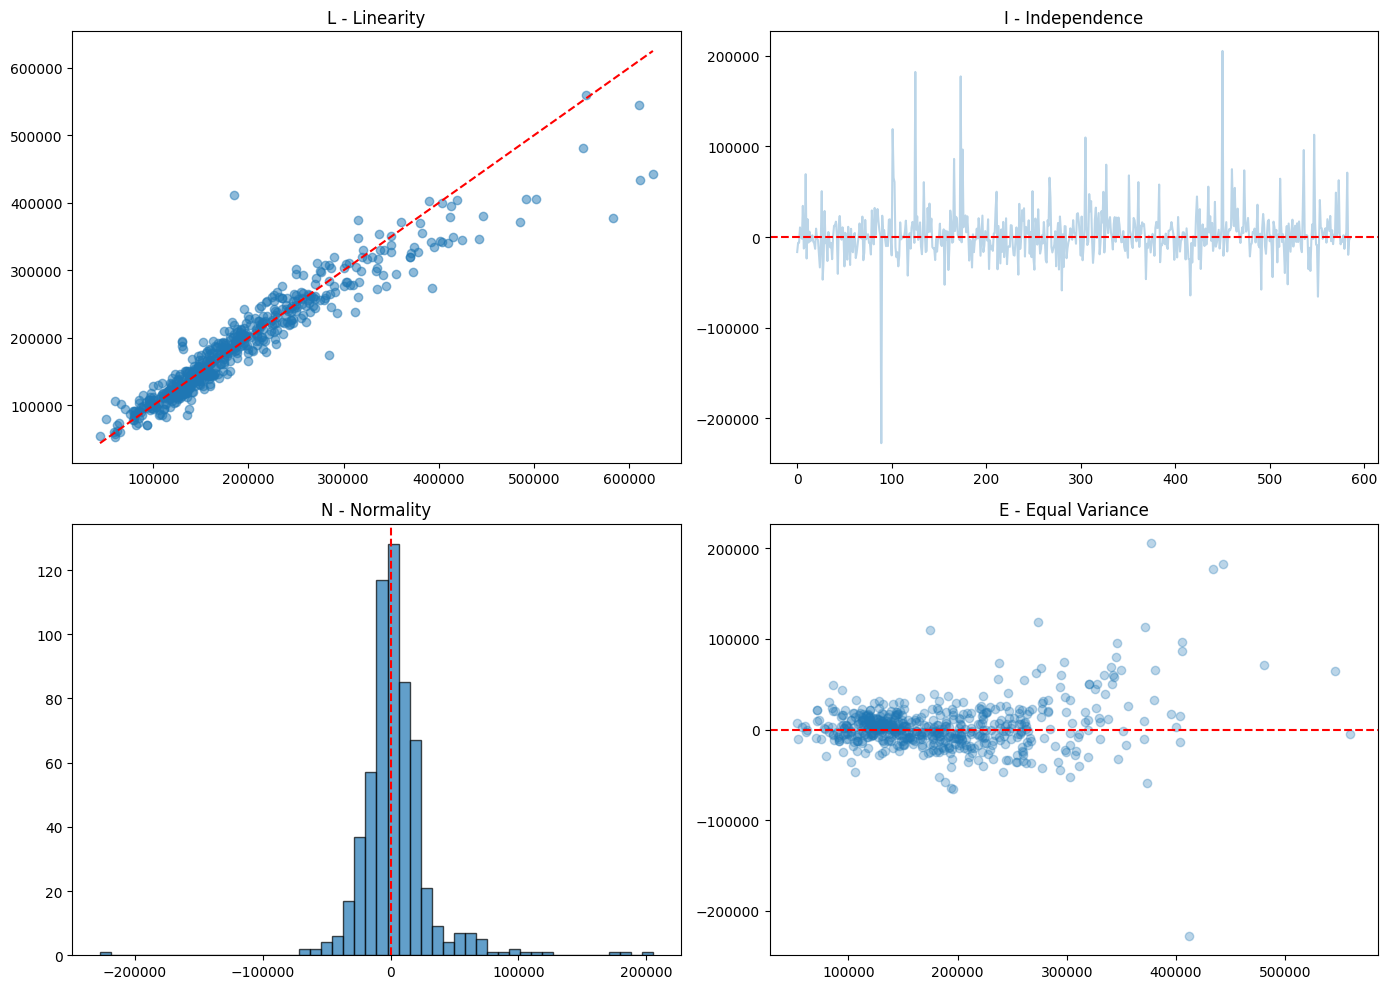


Breusch-Pagan p: 0.0000
D'Agostino p:    0.0000


In [105]:
# ============================================================
# STEP 9: MODEL WITH LOG TARGET
# ============================================================

print("\n--------------- MODEL after feature eng ------------------")

model.fit(X_train_eng, y_train_log)

f_e_pred = np.expm1(model.predict(X_test_eng))
f_e_performance = show_metrics(y_test, f_e_pred, "Test")
r2_f_e = r2_score(y_test, f_e_pred)

# ============================================================
# STEP 10: ASSUMPTION CHECKS (MODEL after feature eng)
# ============================================================

print("\n--------------- Assumption Checks ------------------")

residuals = y_test - f_e_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# L - Linearity
axes[0, 0].scatter(y_test, f_e_pred, alpha=0.5)
min_val = min(y_test.min(), f_e_pred.min())
max_val = max(y_test.max(), f_e_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0, 0].set_title('L - Linearity')

# I - Independence
axes[0, 1].plot(range(len(residuals)), residuals.values, alpha=0.3)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_title('I - Independence')

# N - Normality
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title('N - Normality')

# E - Equal Variance
axes[1, 1].scatter(f_e_pred, residuals, alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('E - Equal Variance')

plt.tight_layout()
plt.savefig('ames_assumptions_clean.png', dpi=150)
plt.show()

# Formal tests
bp_clean = het_breuschpagan(residuals, sm.add_constant(X_test_eng))
dagostino_clean = stats.normaltest(residuals)

print(f"\nBreusch-Pagan p: {bp_clean[1]:.4f}")
print(f"D'Agostino p:    {dagostino_clean[1]:.4f}")


In [106]:
# ============================================================
# STEP 11: SCALE FEATURES
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_eng)
X_test_scaled = scaler.transform(X_test_eng)


# ============================================================
# STEP 12: RIDGE REGRESSION
# ============================================================

print("\n--- Ridge ---")

best_r2_ridge = -1
best_alpha_ridge = None
for alpha in [0.001, 0.01, 0.1, 1, 10, 100]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_log)
    pred = np.expm1(ridge.predict(X_test_scaled))
    r2 = r2_score(y_test, pred)
    print(f"Alpha {alpha:6.3f}: R2 = {r2:.4f}")
    if r2 > best_r2_ridge:
        best_r2_ridge = r2
        best_alpha_ridge = alpha

print(f"\nBest Ridge: alpha={best_alpha_ridge}, R2={best_r2_ridge:.4f}")


# ============================================================
# STEP 13: LASSO REGRESSION
# ============================================================

print("\n--- Lasso ---")
best_r2_lasso = -1
best_alpha_lasso = None

for alpha in [0.0001, 0.001, 0.01, 0.1, 1]:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_log)
    pred = np.expm1(lasso.predict(X_test_scaled))
    r2 = r2_score(y_test, pred)
    print(f"Alpha {alpha:6.4f}: R2 = {r2:.4f}")
    if r2 > best_r2_lasso:
        best_r2_lasso = r2
        best_alpha_lasso = alpha

print(f"\nBest Lasso: alpha={best_alpha_lasso}, R2={best_r2_lasso:.4f}")




--- Ridge ---
Alpha  0.001: R2 = 0.8999
Alpha  0.010: R2 = 0.8999
Alpha  0.100: R2 = 0.8998
Alpha  1.000: R2 = 0.8995
Alpha 10.000: R2 = 0.8961
Alpha 100.000: R2 = 0.8670

Best Ridge: alpha=0.001, R2=0.8999

--- Lasso ---
Alpha 0.0001: R2 = 0.8995
Alpha 0.0010: R2 = 0.8949
Alpha 0.0100: R2 = 0.8204
Alpha 0.1000: R2 = 0.6555
Alpha 1.0000: R2 = -0.0777

Best Lasso: alpha=0.0001, R2=0.8995


In [107]:

# ============================================================
# STEP 14: FINAL COMPARISON
# ============================================================

print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)

results = pd.DataFrame({
    "Model": ["Baseline", "Clean", "Eng + Log", "Ridge (eng+log)", "Lasso (eng+log)"]
    , "R2": [test_r2, clean_r2, r2_f_e, best_r2_ridge, best_r2_lasso]
})
print(results.to_string(index=False))



FINAL COMPARISON
          Model       R2
       Baseline 0.835582
          Clean 0.830925
      Eng + Log 0.899887
Ridge (eng+log) 0.899886
Lasso (eng+log) 0.899504


In [108]:
# ============================================================
# STEP 15: SAVE LINEAR MODEL (Winner)
# ============================================================

import joblib

final_model = LinearRegression()
final_model.fit(X_train_scaled, y_train_log)

joblib.dump(final_model, 'ames_best_model.pkl')
joblib.dump(scaler, 'ames_scaler.pkl')
joblib.dump(list(X_train_eng.columns), 'ames_feature_names.pkl')

print(f"\nBest model: Linear Regression (eng + log) with R2 = 0.8999")
print("Saved: ames_best_model.pkl, ames_scaler.pkl, ames_feature_names.pkl")


Best model: Linear Regression (eng + log) with R2 = 0.8999
Saved: ames_best_model.pkl, ames_scaler.pkl, ames_feature_names.pkl
